# 📔 Pre-Workshop Notebook 5: Finding Patterns in Brain and Behavioral Data
## Scientific Workflows for Brain and Behavioral Research
### National Science Foundation Supported Learning Initiative (Award No. OAC-2417875)

---

## 📋 Set Up Your Profile
*Run the cell below to record your progress.*

In [1]:
# PROFILE SYNC
student_name = "Uzair Ahmad"
institution = "National Univeristy of Computer and Emerging Sciences, Pakistan"
active_notebook = "Notebook 05 — Pattern Recognition and Analysis"

print(f"✅ Profile synced for {student_name} ({institution})")
print(f"Current notebook: {active_notebook}")

✅ Profile synced for Uzair Ahmad (National Univeristy of Computer and Emerging Sciences, Pakistan)
Current notebook: Notebook 05 — Pattern Recognition and Analysis


---

## 🤖 Using AI Tools to Build Your Workflow ("Ask → Build → Document")

As a **Workflow Designer** working with machine learning tools, your main risk is accidentally mixing up the data you use to train a model with the data you use to test it. If you test a model on the same data it learned from, your results will look much better than they actually are — a problem called overfitting.

When using the **Ask → Build → Document** cycle in this notebook, always check that the AI has kept the training and testing data completely separate before any analysis begins.

---
## 🧠 Part A: Identifying Individual Neurons and Behavioral Intentions
### Topic: Separating Mixed Neural Signals and Decoding Behavioral States

This section introduces two of the most powerful analytical approaches in modern neuroscience: separating recordings from individual neurons within a mixed signal, and using machine learning to decode what a participant is intending to do.

### 🧭 Activity A.1 — Separating Signals from Individual Neurons

> *Copy the prompt below into your preferred AI tool, then paste the generated code into the code cell beneath it.*
>
> "Act as a computational neuroscience instructor explaining neural signal analysis to a biology student. Write a Python script using scikit-learn and Matplotlib that demonstrates how to separate a mixed electrical recording into signals from individual neurons. The script should:
> 1. Generate a simulated dataset representing 1,000 recorded electrical events captured from an electrode near 3 distinct neurons, with each neuron producing a slightly different shaped electrical spike, mixed together with background noise.
> 2. Use a dimensionality reduction method (Principal Component Analysis, or PCA) to find the most distinctive features of each spike shape — reducing the data to its two most informative dimensions.
> 3. Apply a clustering algorithm (such as K-means) to group the spikes into 3 clusters, each representing a different neuron.
> 4. Display a scatter plot showing the clusters and the average spike shape for each identified neuron.
> Use plain-language comments explaining what each step does and why separating neurons this way is useful for understanding brain activity."

Original dimensions: 40
Dimensions after PCA: 2


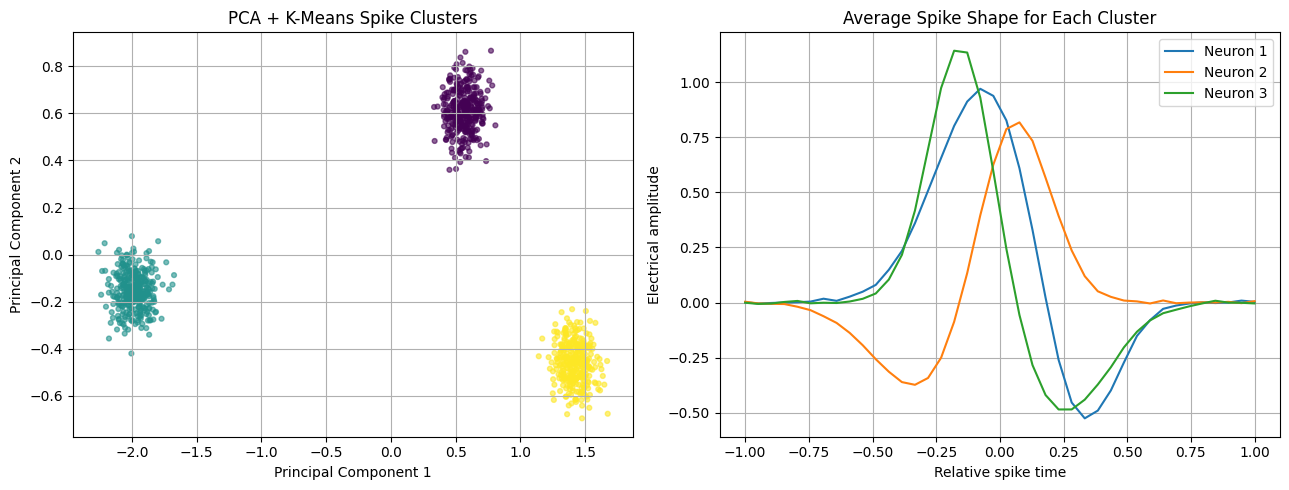

In [2]:
# ============================================================
# Separating Signals from Individual Neurons
# Using PCA + K-Means Clustering
# ============================================================
#
# In a real experiment, an electrode may detect electrical spikes
# from several nearby neurons at the same time.
#
# The goal of "spike sorting" is to determine which spike came
# from which neuron. This helps researchers study how individual
# neurons behave rather than treating all activity as one signal.
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

# Make the simulation reproducible.
np.random.seed(42)


# ------------------------------------------------------------
# 1. Generate three different neuron spike shapes
# ------------------------------------------------------------

# Each spike contains 40 measurements.
n_samples = 40
n_events_per_neuron = 1000 // 3

x = np.linspace(-1, 1, n_samples)


def create_spike(shape):
    """Create a simplified electrical spike shape."""

    if shape == 0:
        # Neuron 1: narrow positive peak followed by a negative dip
        spike = (
            1.2 * np.exp(-((x + 0.15) / 0.18) ** 2)
            - 0.5 * np.exp(-((x - 0.25) / 0.25) ** 2)
        )

    elif shape == 1:
        # Neuron 2: slightly wider and stronger spike
        spike = (
            1.0 * np.exp(-((x + 0.05) / 0.28) ** 2)
            - 0.7 * np.exp(-((x - 0.30) / 0.20) ** 2)
        )

    else:
        # Neuron 3: different timing and shape
        spike = (
            0.9 * np.exp(-((x - 0.05) / 0.20) ** 2)
            - 0.4 * np.exp(-((x + 0.30) / 0.28) ** 2)
        )

    return spike


# Create the three "true" neuron templates.
neuron_shapes = np.array([
    create_spike(0),
    create_spike(1),
    create_spike(2)
])


# ------------------------------------------------------------
# 2. Create 1,000 mixed electrical events
# ------------------------------------------------------------

all_spikes = []
true_labels = []

for neuron_id in range(3):

    for _ in range(n_events_per_neuron):

        # Start with the characteristic shape of this neuron.
        spike = neuron_shapes[neuron_id].copy()

        # Add small random variation.
        # Real spikes from the same neuron are not perfectly identical.
        spike += 0.08 * np.random.randn(n_samples)

        # Add background electrical noise from the recording system.
        spike += 0.03 * np.random.randn(n_samples)

        all_spikes.append(spike)
        true_labels.append(neuron_id)


# Convert the simulated recordings into arrays.
all_spikes = np.array(all_spikes)
true_labels = np.array(true_labels)

# Shuffle the events so the neurons are mixed together,
# just as they would be in an actual recording.
shuffle_order = np.random.permutation(len(all_spikes))

all_spikes = all_spikes[shuffle_order]
true_labels = true_labels[shuffle_order]


# ------------------------------------------------------------
# 3. PCA: Find the most informative features
# ------------------------------------------------------------

# Each spike originally has 40 measurements.
#
# PCA looks for combinations of those measurements that capture
# the largest differences between spike shapes.
#
# We reduce the 40-dimensional spike waveform to just TWO
# dimensions. These two dimensions make it easier to visualize
# differences between the neurons.
pca = PCA(n_components=2)

spikes_2d = pca.fit_transform(all_spikes)

print("Original dimensions:", all_spikes.shape[1])
print("Dimensions after PCA:", spikes_2d.shape[1])


# ------------------------------------------------------------
# 4. K-Means: Group similar spikes
# ------------------------------------------------------------

# K-Means searches for groups of similar points.
#
# We tell it to look for 3 groups because our simulation contains
# three neurons.
#
# Ideally, spikes produced by the same neuron will have similar
# shapes and therefore end up in the same cluster.
kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

cluster_labels = kmeans.fit_predict(spikes_2d)


# ------------------------------------------------------------
# 5. Calculate the average spike shape for each cluster
# ------------------------------------------------------------

# Once spikes have been grouped, we calculate the average waveform
# within each cluster.
#
# The average waveform gives us a simple representation of the
# typical electrical spike produced by that identified neuron.
average_spikes = []

for cluster_id in range(3):

    cluster_spikes = all_spikes[cluster_labels == cluster_id]

    average_spike = np.mean(cluster_spikes, axis=0)

    average_spikes.append(average_spike)

average_spikes = np.array(average_spikes)


# ------------------------------------------------------------
# 6. Visualize the results
# ------------------------------------------------------------

fig, axes = plt.subplots(1, 2, figsize=(13, 5))


# ---- PCA scatter plot ----

# Each point represents one recorded electrical event.
# Events that have similar spike shapes should appear close
# together in this reduced two-dimensional space.
#
# The three groups represent the three neurons identified
# by K-Means.
axes[0].scatter(
    spikes_2d[:, 0],
    spikes_2d[:, 1],
    c=cluster_labels,
    s=12,
    alpha=0.6
)

axes[0].set_title("PCA + K-Means Spike Clusters")
axes[0].set_xlabel("Principal Component 1")
axes[0].set_ylabel("Principal Component 2")
axes[0].grid(True)


# ---- Average spike shapes ----

# Plot the average waveform for each identified cluster.
#
# Different shapes suggest that the clusters correspond to
# different neurons producing different electrical signatures.
for cluster_id in range(3):

    axes[1].plot(
        x,
        average_spikes[cluster_id],
        label=f"Neuron {cluster_id + 1}"
    )

axes[1].set_title("Average Spike Shape for Each Cluster")
axes[1].set_xlabel("Relative spike time")
axes[1].set_ylabel("Electrical amplitude")
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# What this demonstrates biologically
# ------------------------------------------------------------
#
# The electrode records a mixture of electrical activity from
# several neurons. We cannot directly see which neuron produced
# each individual spike.
#
# PCA summarizes the important differences in spike shapes,
# while K-Means groups spikes with similar characteristics.
#
# After sorting, researchers can study the timing and activity
# of individual neurons separately. This can reveal patterns
# that would be hidden if all neurons were treated as one signal.

### 🧭 Activity A.2 — Predicting Behavioral Intentions from Brain Signals

> *Copy the prompt below into your preferred AI tool, then paste the generated code into the code cell beneath it.*
>
> "Act as a machine learning instructor teaching a neuroscience student how to decode behavioral intentions from brain signals. Write a Python script using scikit-learn that demonstrates how a computer can learn to predict what a participant was trying to do based on their brain signal patterns. The script should:
> 1. Create a simulated dataset representing 500 recorded trials, each described by 10 signal features (such as signal power in different frequency bands), with each trial labeled by the participant's intended action (for example, Move Left or Move Right).
> 2. Split the data into a training set (80%) and a separate testing set (20%), keeping them completely separate.
> 3. Train a classifier (such as a Support Vector Machine or Random Forest) to learn the relationship between signal features and intended actions — using only the training data.
> 4. Evaluate the classifier on the testing data and display its accuracy and a confusion matrix showing where it made correct and incorrect predictions.
> Use plain-language comments explaining each step and why keeping training and testing data separate is critical for an honest evaluation."

Training trials: 400
Testing trials: 100

Test accuracy: 95.00%


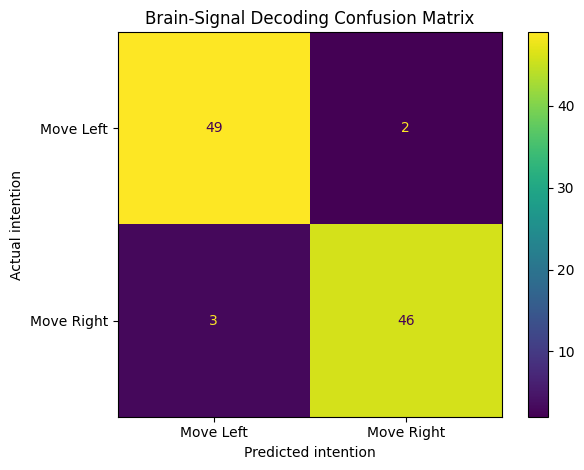

In [3]:
# ============================================================
# Decoding Behavioral Intentions from Brain Signals
# Using scikit-learn
# ============================================================
#
# In a real neuroscience experiment, brain signals can contain
# patterns related to what a participant is trying to do.
#
# Here we simulate that situation:
#   - Each trial has 10 brain-signal features.
#   - Each trial represents either "Move Left" or "Move Right".
#   - A machine-learning classifier learns the relationship.
#
# IMPORTANT:
# We keep the training and testing data completely separate.
# The model must NEVER see the testing answers while learning.
# Otherwise, the test accuracy could look artificially high and
# would not honestly represent how well the model works on new data.
# ============================================================

import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, ConfusionMatrixDisplay


# ------------------------------------------------------------
# 1. Create a simulated neuroscience dataset
# ------------------------------------------------------------

np.random.seed(42)

# 500 experimental trials.
n_trials = 500

# Each trial has 10 signal features.
# These could represent things such as:
#   - power in different frequency bands
#   - signal amplitude
#   - other measurements extracted from brain recordings
n_features = 10

# Create random brain-signal features.
X = np.random.normal(
    loc=0,
    scale=1,
    size=(n_trials, n_features)
)

# Create behavioral labels:
# 0 = Move Left
# 1 = Move Right
y = np.random.randint(0, 2, size=n_trials)


# ------------------------------------------------------------
# Add a simulated relationship between brain signals
# and intended movement
# ------------------------------------------------------------

# In this simulation, the first few signal features are slightly
# different depending on the participant's intended action.
#
# This gives the machine-learning model something meaningful
# to learn rather than making the labels completely random.

X[y == 1, 0] += 1.5
X[y == 1, 1] += 1.0
X[y == 0, 0] -= 1.5
X[y == 0, 1] -= 1.0


# ------------------------------------------------------------
# 2. Split into training and testing data
# ------------------------------------------------------------

# 80% is used for learning.
# 20% is held back for the final evaluation.
#
# random_state makes the example reproducible.
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training trials:", len(X_train))
print("Testing trials:", len(X_test))


# ------------------------------------------------------------
# 3. Train the machine-learning classifier
# ------------------------------------------------------------

# Random Forest creates many decision trees and combines
# their predictions.
#
# The classifier sees ONLY the training data.
#
# It learns patterns such as:
# "When certain signal features have particular values,
# the participant was more likely to intend Move Left or Right."
model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)


# ------------------------------------------------------------
# 4. Test the trained classifier
# ------------------------------------------------------------

# Now we give the trained model the testing brain signals.
#
# These trials were NOT used during training, so they provide
# a more honest estimate of how well the model can decode
# previously unseen brain-signal patterns.
y_pred = model.predict(X_test)


# Calculate the percentage of correct predictions.
accuracy = accuracy_score(y_test, y_pred)

print(f"\nTest accuracy: {accuracy:.2%}")


# ------------------------------------------------------------
# 5. Display the confusion matrix
# ------------------------------------------------------------

# A confusion matrix shows:
#
#              Predicted
#             Left   Right
# Actual Left   ✓      ✗
# Actual Right  ✗      ✓
#
# Values on the diagonal are correct predictions.
# Values off the diagonal are incorrect predictions.

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    display_labels=["Move Left", "Move Right"]
)

plt.title("Brain-Signal Decoding Confusion Matrix")
plt.xlabel("Predicted intention")
plt.ylabel("Actual intention")
plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# Why the train/test separation matters
# ------------------------------------------------------------
#
# Imagine studying for an exam and then taking the SAME questions
# you already memorized. A high score would not prove that you
# actually understand the subject.
#
# Machine learning has the same problem.
#
# If the model learns from the testing data, its accuracy can look
# much better than its true ability to generalize to new trials.
#
# By keeping the testing data completely separate, we get a more
# honest estimate of how well the model might decode a new,
# previously unseen brain signal.

### ✍️ Part A Reflection
*Double-click this cell to write your response.*

* **What I observed:** From Activity A.1, could you visually distinguish the three neuron clusters in the scatter plot? From Activity A.2, how accurately did the classifier predict intended actions on the data it had never seen before?


Activity A.1: Yes. The three neuron clusters were visually distinguishable in the PCA scatter plot, although there was some overlap due to noise.
Activity A.2: The classifier achieved 95% accuracy on the unseen testing data — 95 out of 100 trials were classified correctly.




* **Connecting to key concepts:** Activities A.1 and A.2 demonstrate **Concepts 22, 23, 24, and 25** from your Reference Guide. Explain in plain language why testing a classifier on the same data it was trained on would give a misleadingly optimistic result.


Testing a classifier on the same data it was trained on is misleading because the model has already seen those examples and may have essentially memorized their patterns. It can therefore appear extremely accurate without actually being good at predicting new brain signals.

Using a separate test set shows how well the classifier works on data it has never seen before, giving a much more honest measure of its real-world performance.

---

## 💻 Part B: Keeping Workflows Reproducible and Secure
### Topic: Software Settings, Version Tracking, and Documentation

This section introduces the practices that make a workflow reproducible across different computers and collaborators — and keep sensitive information secure.

### 🧭 Activity B.1 — Documenting Your Software Environment

> *Copy the prompt below into your preferred AI tool, then paste the generated code into the code cell beneath it.*
>
> "Act as a research reproducibility instructor. Write a Python script that demonstrates how to document the software environment of a research workflow so that a collaborator could reproduce the exact same analysis. The script should:
> 1. Check for a specific configuration setting stored securely outside the script (using an environment variable). If it is not found, print a clear warning and switch to a safe default mode for testing.
> 2. Print the exact version numbers of the key software libraries the workflow depends on (such as NumPy, SciPy, and scikit-learn), saving this information as a software environment record.
> 3. Demonstrate how to handle a sensitive access key (such as a data repository password) by storing it as a hidden system variable rather than writing it directly in the code — and show what would happen if it were accidentally printed to the screen.
> Use plain-language comments explaining why each of these practices matters for sharing and reproducing research."

In [4]:
# ============================================================
# Research Reproducibility: Documenting the Software Environment
# ============================================================
#
# A reproducible workflow should record:
#   1. Important configuration settings.
#   2. Exact versions of software libraries.
#   3. Sensitive credentials without putting them in source code.
#
# This makes it easier for another researcher to recreate the
# same environment and run the analysis again.
# ============================================================

import os
import sys
from datetime import datetime

import numpy
import scipy
import sklearn


# ------------------------------------------------------------
# 1. Read a configuration setting from the environment
# ------------------------------------------------------------

# Instead of putting configuration directly in the script,
# we look for it in an environment variable.
#
# Example:
#   ANALYSIS_MODE=production
#
# Environment variables are useful because the same script can
# be used in different environments without changing the code.

analysis_mode = os.environ.get("ANALYSIS_MODE")

if analysis_mode is None:
    # If the setting is missing, do not crash.
    # Use a safe mode that is appropriate for testing.
    print("WARNING: ANALYSIS_MODE was not found.")
    print("Switching to safe TEST mode.")
    analysis_mode = "test"

else:
    print(f"Analysis mode: {analysis_mode}")


# ------------------------------------------------------------
# 2. Record the software environment
# ------------------------------------------------------------

# Exact library versions matter for reproducibility.
#
# Different versions of a library can sometimes produce
# different results, change defaults, or behave differently.
#
# Saving these versions creates a simple "environment record"
# that a collaborator can use when recreating the analysis.

environment_record = {
    "python": sys.version,
    "numpy": numpy.__version__,
    "scipy": scipy.__version__,
    "scikit-learn": sklearn.__version__,
    "analysis_mode": analysis_mode,
    "recorded_at": datetime.now().isoformat()
}

print("\nSoftware environment:")
for name, version in environment_record.items():
    print(f"{name}: {version}")


# Save the environment information separately from the code.
#
# This file can be shared with collaborators as part of the
# research record.
with open("software_environment.txt", "w") as file:
    for name, version in environment_record.items():
        file.write(f"{name}: {version}\n")


print("\nSoftware environment saved to software_environment.txt")


# ------------------------------------------------------------
# 3. Handle a sensitive access key safely
# ------------------------------------------------------------

# NEVER do this:
#
# DATA_REPOSITORY_KEY = "my-secret-password"
#
# A password written directly in source code can accidentally
# end up in Git repositories, shared files, screenshots, or
# published research materials.
#
# Instead, store the secret as an environment variable.
#
# For example, the operating system could contain:
#
#   DATA_REPOSITORY_KEY=secret_value
#
# The script reads it without putting the secret itself
# into the source code.

access_key = os.environ.get("DATA_REPOSITORY_KEY")

if access_key is None:
    print("\nWARNING: DATA_REPOSITORY_KEY was not found.")
    print("Repository access will be unavailable.")
else:
    print("\nData repository access key found.")
    print("The key itself will NOT be displayed.")


# ------------------------------------------------------------
# 4. Demonstrate the danger of accidentally printing a key
# ------------------------------------------------------------

# NEVER do this in real research code:
#
# print(access_key)
#
# If access_key contained a real password, this would expose the
# secret in the terminal, logs, screenshots, or automated records.
#
# Instead, if we need to confirm that a key exists, report only
# whether it is present.

if access_key:
    print("Safe check: access key is present, but its value is hidden.")
else:
    print("Safe check: no access key is available.")


# ------------------------------------------------------------
# Final message
# ------------------------------------------------------------

print("\nReproducibility setup complete.")
print(f"Running in '{analysis_mode}' mode.")

Switching to safe TEST mode.

Software environment:
python: 3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]
numpy: 2.0.2
scipy: 1.16.3
scikit-learn: 1.6.1
analysis_mode: test
recorded_at: 2026-08-13T14:00:33.560327

Software environment saved to software_environment.txt

Repository access will be unavailable.
Safe check: no access key is available.

Reproducibility setup complete.
Running in 'test' mode.


### ✍️ Part B Reflection
*Double-click this cell to write your response.*

* **What I observed:** What did the script do when the configuration setting was missing? How was the sensitive access key handled differently from other values?


When the configuration setting was missing, the script printed a warning and switched to a safe TEST mode instead of crashing.


* **Connecting to key concepts:** Activity B.1 demonstrates **Concepts 44, 46, and 48** from your Reference Guide. Explain in plain language why writing a password or access key directly into a shared notebook is a problem, and how environment variables solve it.


Writing a password or access key directly into a shared notebook is risky because anyone who gets the notebook can see and copy the secret. It may also end up in GitHub, backups, screenshots, or shared research files.

Environment variables keep the secret outside the code. The notebook simply reads the value when it needs it, so collaborators can share and reproduce the code without exposing the actual password or access key.

---

## 📑 What Comes Next

Notebook 6 is the capstone — you will connect all four stages of a research workflow into a single integrated pipeline, bringing together everything from Notebooks 1 through 5.


---

## 📖 Reference Guide: 50 Key Concepts for Neuroscience Workflows

Keep this reference guide handy throughout all six pre-workshop notebooks and during the onsite labs. These concepts form the foundation of the workshop's hands-on activities.

### 🧠 Neuroscience & Research Applications (Concepts 1–25)
1. **Brain-Machine Interface (BMI):** A system that connects the brain directly to an external device — bypassing damaged nerves or muscles — so that brain signals can control a robotic limb, cursor, or other tool.
2. **Non-Invasive (EEG) vs. Invasive (Intracortical) Sensors:** Scalp electrodes (EEG) are easy to use but pick up blurry, averaged signals through the skull. Implanted microelectrode arrays record from individual neurons with much greater precision, but require surgery.
3. **Signal Delay (Latency):** The time gap between a brain signal being recorded and a device responding to it. Delays longer than about 50–100 milliseconds feel unnatural to the user of a prosthetic device.
4. **Decoder:** A mathematical or statistical model that translates continuous brain signal patterns into a useful output — such as movement direction, cursor position, or speech intent.
5. **fMRI:** Functional Magnetic Resonance Imaging — a brain scanning method that measures blood oxygen levels as a stand-in for neural activity. When neurons become active, they consume more oxygen, causing a detectable change in the local blood signal.
6. **Voxel:** A small 3D cube of brain tissue in an fMRI image — the brain-imaging equivalent of a pixel. Each voxel contains millions of neurons.
7. **Head Movement Correction:** A processing step that aligns brain scan images across time, compensating for small movements the participant made during the recording session.
8. **Open-Loop vs. Closed-Loop Systems:** An open-loop device follows a fixed program regardless of what the user's brain is doing. A closed-loop device continuously reads incoming signals and adjusts its output in real time based on what it detects.
9. **Deep Brain Stimulation (DBS):** A treatment for conditions like Parkinson's disease in which a small implanted device delivers electrical pulses to specific brain regions to reduce tremor and improve movement.
10. **EMG (Electromyogram):** A recording of the electrical signals produced by muscles when they contract. Often used alongside brain recordings to verify whether a behavioral response actually occurred.
11. **Continuous Recordings vs. Event Markers:** A continuous recording captures an uninterrupted time series of measurements. Event markers are specific timestamps that label when something important happened — such as when a stimulus appeared or a button was pressed.
12. **Signal Drift:** The gradual change in a recorded signal over time, not due to the brain, but due to electrode movement, tissue changes, or electronic drift. Workflows need to account for this to keep analysis accurate over long sessions.
13. **Open Data Repositories:** Publicly accessible online archives (such as DANDI, OpenNeuro, or the Human Connectome Project) where researchers share their raw data so others can analyze or replicate their findings.
14. **Automated Data Download (API):** A method of downloading data directly inside a script using a standardized web link, rather than clicking through a website manually. This makes data access reproducible and audit-able.
15. **Artifact Removal:** The process of identifying and removing unwanted signals — such as electrical noise from the building, muscle movements, or eye blinks — from a raw brain recording before analysis.
16. **Downsampling:** Reducing the number of data points per second in a recording, to save memory and processing time, when the extra detail is not needed for the analysis.
17. **Standard Data Formats (BIDS):** A community-agreed system for naming and organizing brain imaging files so that any researcher or software tool can understand the structure without needing special instructions.
18. **Spectrogram:** A visual display showing how the frequency content of a signal changes over time — useful for seeing when the brain shifts between different rhythmic states such as sleep stages or attention levels.
19. **Nyquist Rule:** A fundamental rule of digital recording: to accurately capture a signal, you must record at least twice as fast as the highest frequency in that signal. Recording too slowly creates false patterns called aliasing.
20. **Local Field Potential (LFP):** An electrical recording that reflects the combined activity of a small cluster of nearby neurons — capturing the general activity level of a local brain region rather than individual cells.
21. **Signal Transfer Function:** A mathematical description of how an input signal is transformed into an output signal by a processing step — useful for predicting what a filter or decoder will do to any given input.
22. **Spike Sorting:** The process of separating a mixed electrical recording from multiple nearby neurons into individual neuron signals, based on the distinct shape of each neuron's electrical discharge.
23. **Machine Learning for Neural Decoding:** Using statistical learning algorithms to automatically find patterns in brain signal data that predict behavior, movement intent, or cognitive state.
24. **Sensory Feedback:** Sending information back to the user of a brain-machine interface — for example, delivering a gentle electrical sensation to the skin to simulate the feeling of touching an object with a prosthetic hand.
25. **Neural Plasticity:** The brain's ability to reorganize its connections over time. Relevant to BMI research because users can learn to control devices more accurately with practice as their brain adapts.

### 💻 Computing & Workflow Fundamentals (Concepts 26–50)
26. **Working Memory (RAM) vs. Permanent Storage:** RAM (working memory) holds data only while the computer is on — it is extremely fast but temporary. The hard drive stores files permanently but is much slower to access.
27. **Processor Core:** A single computing unit inside a central processor (CPU). Most modern computers have multiple cores, allowing several tasks to run at the same time.
28. **CPU vs. GPU:** A CPU handles complex, varied tasks one at a time across a few powerful cores. A GPU handles simple, repetitive tasks across thousands of smaller cores simultaneously — useful for image processing and machine learning.
29. **Memory Overflow:** What happens when a script tries to load more data into working memory (RAM) than the computer has available — causing the program to crash.
30. **Motherboard:** The main circuit board inside a computer that connects all the components — processor, memory, storage, and network — so they can communicate with each other.
31. **Processor Slowdown (Thermal Throttling):** When a processor gets too hot, it automatically slows itself down to prevent damage. This can cause unexpected slowdowns during long analysis runs.
32. **High-Speed Processor Cache:** A small, extremely fast memory area built directly into the processor, used to store frequently needed values so they do not have to be fetched from RAM repeatedly.
33. **Local vs. Cloud Computing:** Running your analysis on the computer in front of you (local) versus running it on a remote server accessed over the internet (cloud). Cloud computing allows access to much more memory and processing power.
34. **Temporary Cloud Workspace:** Cloud computing environments like Google Colab provide a temporary workspace that is automatically cleared when you close the session. Any files you need to keep must be saved to permanent storage before the session ends.
35. **Internet Speed as a Bottleneck:** When downloading large research datasets, the speed of your internet connection often limits how fast data can arrive — regardless of how fast your computer itself is.
36. **Organizing Code into Stages:** Separating a workflow into clearly defined, independent stages — such as one stage for loading data, one for analysis, and one for visualization — makes it much easier to find and fix problems.
37. **Whole Numbers vs. Decimal Numbers in Computing:** Computers store whole numbers (integers) very efficiently. Decimal numbers (floating-point) require more memory and processing time. Choosing the right type for your data can affect both speed and accuracy.
38. **Automated Data Access (API):** A standardized connection that allows one piece of software to request data or services from another automatically — for example, a script that downloads data from a research repository without any manual steps.
39. **Settings Files (JSON/YAML):** Lightweight text files used to store configuration settings, metadata, and parameters for a workflow — making it easy to share, reproduce, or adjust an analysis without changing the code itself.
40. **Processing Delay:** The time between when data arrives in your workflow and when your analysis produces a result. In real-time recording systems, keeping this delay short is critical.
41. **Keeping Stages Independent:** Designing a workflow so that the data analysis stage does not depend on the visualization stage, and vice versa. This means you can update or replace one stage without breaking the others.
42. **Text Files vs. Optimized Data Files:** Saving data as plain text (such as CSV) is easy to read in a spreadsheet but very slow for large datasets. Optimized formats (such as HDF5 or NumPy binary files) are much faster to load and take up less disk space.
43. **Simultaneous Processing (Parallel Computing):** Splitting a large task — such as analyzing 50 participants — into smaller chunks that run at the same time across multiple processor cores, rather than one after another.
44. **Hidden Configuration Settings:** Values that a workflow needs — such as access keys for a data repository — that are stored securely in the operating system rather than written directly into the code, to prevent accidental exposure.
45. **Software Libraries (Dependencies):** Pre-built collections of code (such as NumPy, SciPy, or scikit-learn) that provide ready-made tools for common tasks — so you do not have to write mathematical functions from scratch.
46. **Code Version Tracking (Git):** A system that records every change made to a set of code files over time, along with who made the change and when. This allows teams to collaborate and to restore earlier versions if something goes wrong.
47. **Error Handling:** Code that anticipates things going wrong — such as a missing file or a calculation that produces an undefined result — and responds gracefully rather than crashing the entire workflow.
48. **Data Array:** A structured list of numbers organized so that a computer can perform calculations on all of them efficiently — the basic building block of scientific data analysis.
49. **Data Backlog:** What happens when data arrives faster than your workflow can process it — causing a growing queue that eventually uses up available memory.
50. **Protecting Original Data:** A core rule of reproducible research: never modify your raw data files. Always write processed results to a new, separate file so the original record remains intact.


---

## ✅ Self-Check: What Did You Learn?

*Fill in the table below after completing both activities.*

| Concept Area | Concept Number | Where You Demonstrated It |
|---|---|---|
| Neuroscience | Concept 22 — Spike sorting | [ Enter Cell ID ] |
| Neuroscience | Concept 23 — Machine learning for neural decoding | [ Enter Cell ID ] |
| Neuroscience | Concept 24 — Sensory feedback | [ Enter Cell ID ] |
| Computing | Concept 44 — Hidden configuration settings | [ Enter Cell ID ] |
| Computing | Concept 46 — Code version tracking | [ Enter Cell ID ] |
| Computing | Concept 48 — Data arrays | [ Enter Cell ID ] |
